  File "C:\Users\deeksha.c.s\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\deeksha.c.s\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\deeksha.c.s\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\deeksha.c.s\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umas

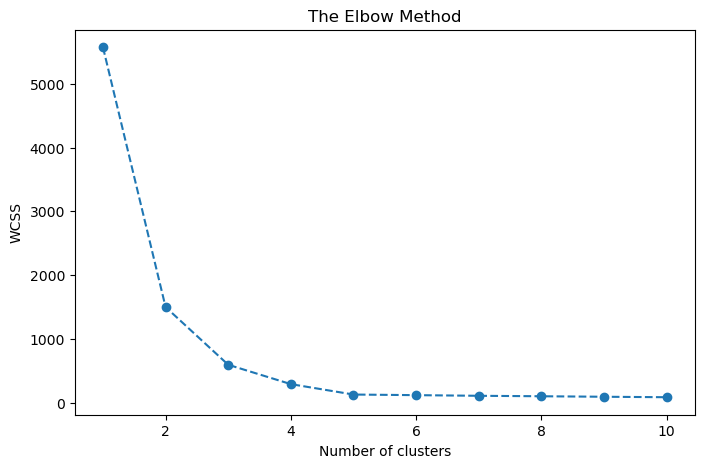

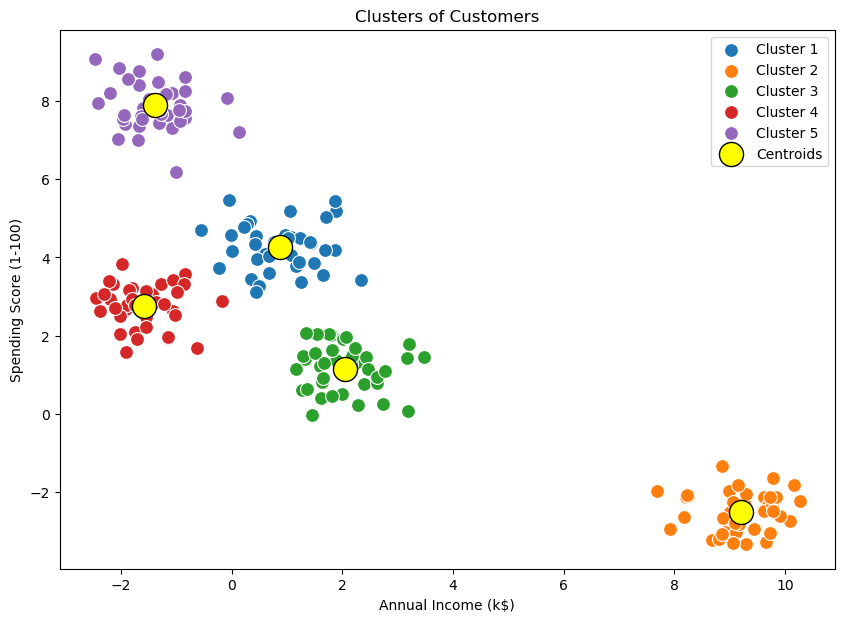

Clustering complete. Centroids are located at:
[[ 0.87493583  4.2620895 ]
 [ 9.19806882 -2.50247405]
 [ 2.05479441  1.15373547]
 [-1.58063033  2.76879457]
 [-1.3914031   7.90274995]]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.cluster import KMeans

# Ignore all warnings
warnings.filterwarnings("ignore")

# 1. Load the dataset
# Ensure 'Mall_Customers.csv' is in your working directory
# df = pd.read_csv('Mall_Customers.csv')

# For demonstration, creating a synthetic version of the Mall Customer Dataset
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=200, centers=5, cluster_std=0.60, random_state=0)
df = pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)'])

# 2. Select features for clustering
# Usually, we use Annual Income (Index 3) and Spending Score (Index 4)
data = df.iloc[:, [0, 1]].values

# 3. The Elbow Method to find the optimal number of clusters (K)
wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Training the K-means model on the dataset
# Based on the elbow, 5 is usually the optimal number for this dataset
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(data)

# 5. Visualizing the Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data[y_kmeans == 0, 0], y=data[y_kmeans == 0, 1], s=100, label='Cluster 1')
sns.scatterplot(x=data[y_kmeans == 1, 0], y=data[y_kmeans == 1, 1], s=100, label='Cluster 2')
sns.scatterplot(x=data[y_kmeans == 2, 0], y=data[y_kmeans == 2, 1], s=100, label='Cluster 3')
sns.scatterplot(x=data[y_kmeans == 3, 0], y=data[y_kmeans == 3, 1], s=100, label='Cluster 4')
sns.scatterplot(x=data[y_kmeans == 4, 0], y=data[y_kmeans == 4, 1], s=100, label='Cluster 5')

# Plotting centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='yellow', label='Centroids', edgecolors='black')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

print("Clustering complete. Centroids are located at:")
print(kmeans.cluster_centers_)